In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os
import matplotlib.ticker as mticker

def autocorrelation_matrix(X, lag):
    X_t = X.iloc[lag:]
    X_tk = X.shift(lag).iloc[lag:]

    mu = X_t.mean().values

    Xc_t = X_t.values - mu
    Xc_tk = X_tk.values - mu

    Sigma_k = (Xc_tk.T @ Xc_t) / len(Xc_t)

    var = X.var(ddof=0).values
    D_inv_sqrt = np.diag(1 / np.sqrt(var))

    return D_inv_sqrt @ Sigma_k @ D_inv_sqrt

k_values = [1, 10]

In [ ]:
def out_of_sample_lead_lag(n_months: int):
    years = range(2019, 2025)
    centralities = ["central", "peripheral"]
    portfolios = {}

    # 1. Load Data
    for year in years:
        for centrality in centralities:
            for k in k_values:
                # Path to CSV
                path_csv = f"../../data/06_portfolios/{centrality}_{year}_{k}.csv"
                cols = pd.read_csv(path_csv, index_col="Date").columns.tolist()
                
                end_date = (
                    pd.Timestamp(year=year + 1, month=n_months, day=1)
                    + pd.offsets.MonthEnd(0)
                )
                
                # Load returns
                path_ret = f"../../data/02_clean/returns_{year + 1}.parquet"
                portfolios[f"{centrality}_{year}_{k}"] = pd.read_parquet(path_ret).loc[:end_date, cols]

    # 2. Resample Returns
    weekly_returns = {}
    daily_returns = {}
    weekly2_returns = {}
    monthly_returns = {}
    for name, portfolio in portfolios.items():
        log_returns = np.log1p(portfolio)
        # Aggregating across stocks in the portfolio (mean)
        daily_returns[name] = log_returns.mean(axis=1)
        weekly_returns[name] = log_returns.resample("W-FRI").sum().mean(axis=1)
        weekly2_returns[name] = log_returns.resample("2W-FRI").sum().mean(axis=1)
        monthly_returns[name] = log_returns.resample("ME").sum().mean(axis=1)

    # 3. Build Lead-Lag Dataframes
    leadlag_by_k = {}
    for k in k_values:
        temp_list = [] # Use a list for concat
        for year in years:
            # Pair corresponding returns
            pairs = [
                (daily_returns[f"peripheral_{year}_{k}"], daily_returns[f"central_{year}_{k}"]),
                (weekly_returns[f"peripheral_{year}_{k}"], weekly_returns[f"central_{year}_{k}"]),
                (weekly2_returns[f"peripheral_{year}_{k}"], weekly2_returns[f"central_{year}_{k}"]),
                (monthly_returns[f"peripheral_{year}_{k}"], monthly_returns[f"central_{year}_{k}"])
            ]

            matrix = []
            for R_peri, R_cent in pairs:
                X = pd.concat([R_peri, R_cent], axis=1).dropna()
                X.columns = ["Peripheral", "Central"]
                
                # Assumes autocorrelation_matrix is defined in your environment
                acm = autocorrelation_matrix(X, lag=1)
                lag_matrix = acm - acm.T
                matrix.append(lag_matrix[1, 0])

            # Store result for the year
            df_year = pd.DataFrame(
                [matrix], 
                index=[year + 1], 
                columns=["cp1d", "cp1w", "cp2w", "cp1m"]
            )
            temp_list.append(df_year)

        # FIX: Concat the list of DataFrames
        leadlag_by_k[k] = pd.concat(temp_list)

    # --- PLOTTING (Paper Style) ---
    sns.set_theme(style="whitegrid", context="paper")
    palette = sns.color_palette("colorblind")

    TITLE_SIZE, LABEL_SIZE = 25, 22
    TICK_SIZE, LEGEND_SIZE = 18, 18
    LINE_WIDTH, MARKER_SIZE = 2.5, 9

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=True)
    axes_flat = axes.flatten()

    panels = [
        ("cp1d", f"Next {n_months}-Months: 1-Day Lag"),
        ("cp1w", f"Next {n_months}-Months: 1-Week Lag"),
        ("cp2w", f"Next {n_months}-Months: 2-Weeks Lag"),
        ("cp1m", f"Next {n_months}-Months: 1-Month Lag"),
    ]

    k_styles = {
        k_values[0]: {"color": palette[0], "label": f"$k={k_values[0]}$", "marker": "o"},
        k_values[1]: {"color": palette[1], "label": f"$k={k_values[1]}$", "marker": "s"},
    }

    legend_handles = []
    for i, (ax, (col, title)) in enumerate(zip(axes_flat, panels)):
        for k, style in k_styles.items():
            df = leadlag_by_k[k]
            line, = ax.plot(
                df.index, df[col],
                lw=LINE_WIDTH, color=style["color"],
                marker=style["marker"], markersize=MARKER_SIZE,
                label=style["label"], alpha=0.85
            )
            if i == 0: legend_handles.append(line)

        ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold", pad=15)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.axhline(0, color="black", linewidth=2, linestyle="--", alpha=0.6)
        
        if i >= 2: ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold")
        if i % 2 == 0: ax.set_ylabel("Lead–Lag Measure", fontsize=LABEL_SIZE, fontweight="bold")
        
        ax.grid(alpha=0.3)

    fig.legend(
        legend_handles, [h.get_label() for h in legend_handles],
        loc="lower center", ncol=2, frameon=False,
        fontsize=LEGEND_SIZE, title="Estimation Window ($k$)",
        title_fontsize=LEGEND_SIZE + 2, bbox_to_anchor=(0.5, -0.02)
    )

    sns.despine(fig=fig)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig(f"../../figures/oos_leadlag_{n_months}.png", dpi=300, bbox_inches="tight")
    plt.show()

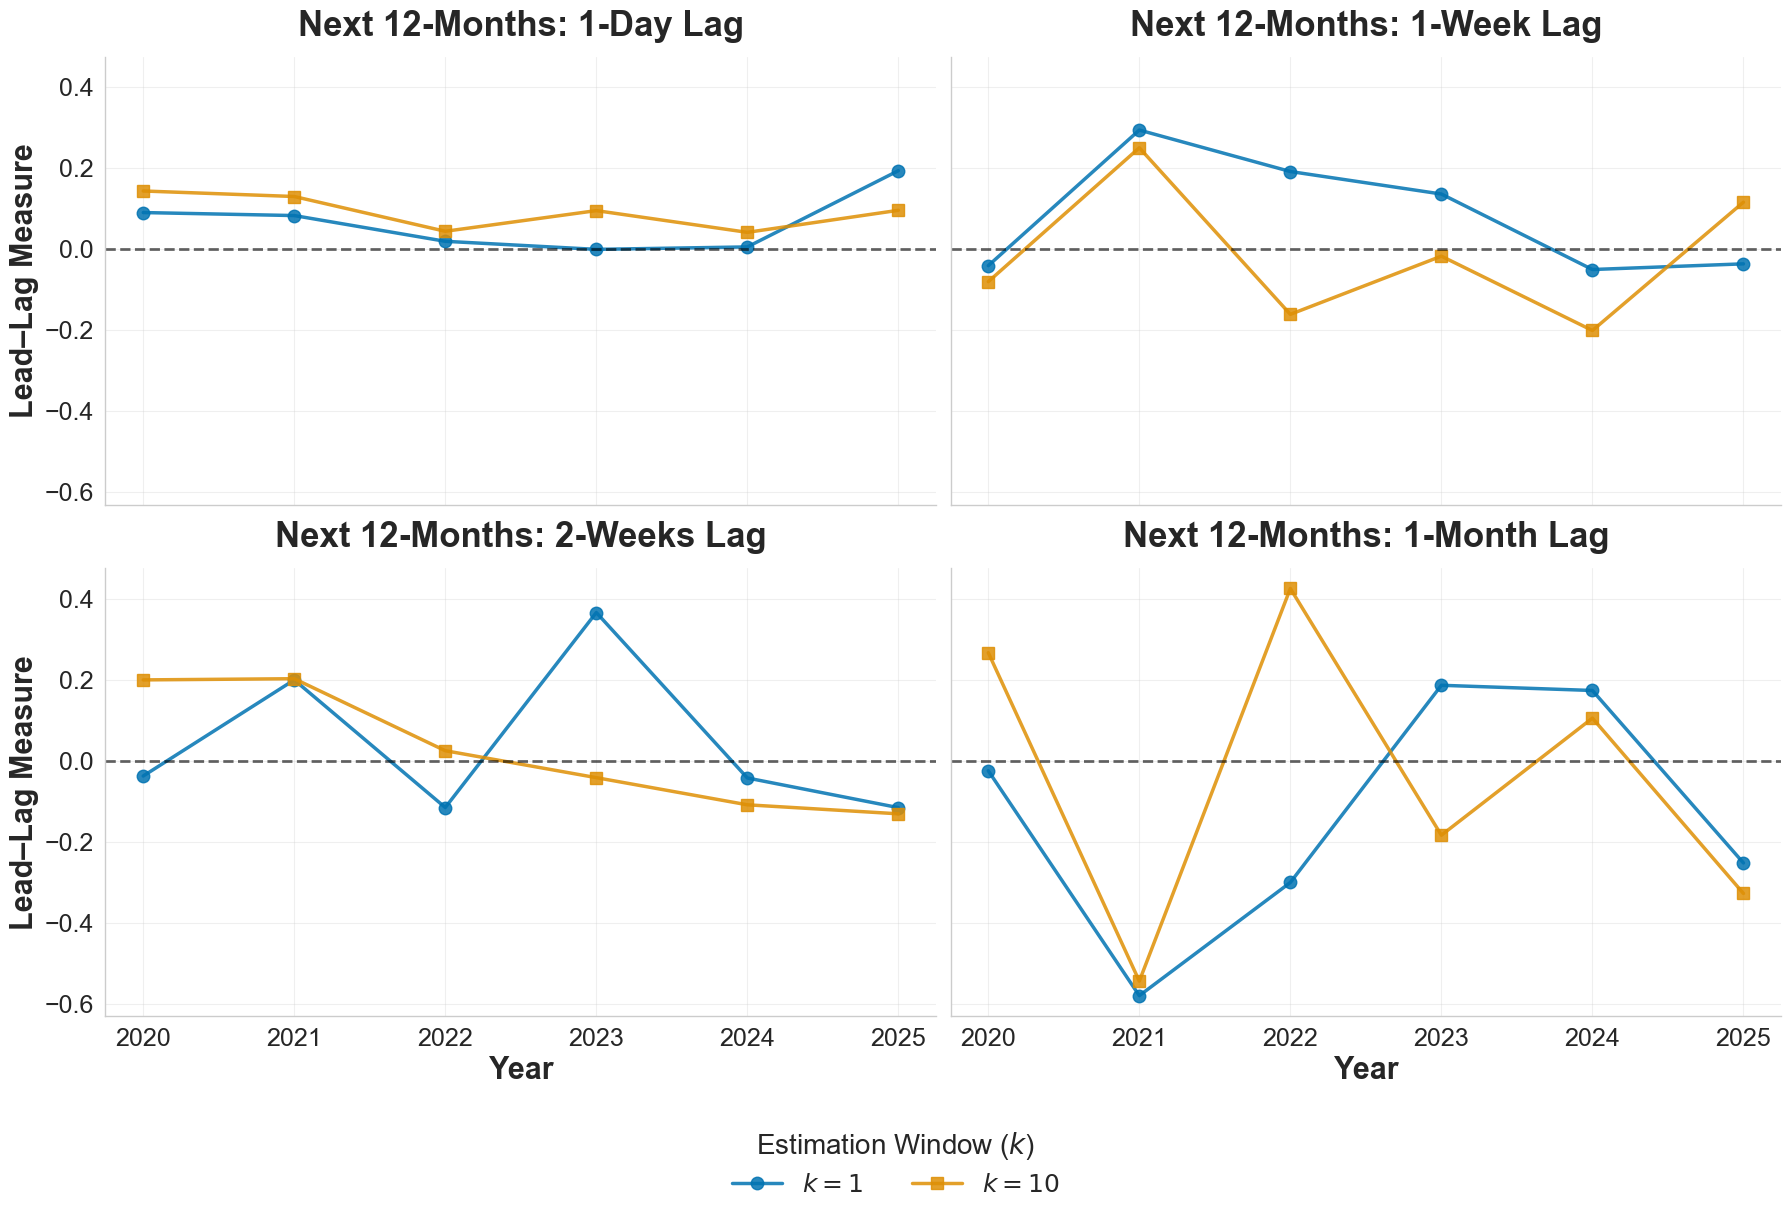

In [3]:
out_of_sample_lead_lag(n_months=12)

In [6]:
def out_of_sample_lead_lag(n_months: int):
    years = range(2019, 2025)
    centralities = ["central", "peripheral"]
    portfolios = {}

    # 1. Load Data
    for year in years:
        for centrality in centralities:
            for k in k_values:
                # Path to CSV
                path_csv = f"../../data/06_portfolios/{centrality}_{year}_{k}.csv"
                cols = pd.read_csv(path_csv, index_col="Date").columns.tolist()
                
                end_date = (
                    pd.Timestamp(year=year + 1, month=n_months, day=1)
                    + pd.offsets.MonthEnd(0)
                )
                
                # Load returns
                path_ret = f"../../data/02_clean/returns_{year + 1}.parquet"
                portfolios[f"{centrality}_{year}_{k}"] = pd.read_parquet(path_ret).loc[:end_date, cols]

    # 2. Resample Returns
    weekly_returns = {}
    daily_returns = {}
    weekly2_returns = {}
    monthly_returns = {}
    for name, portfolio in portfolios.items():
        log_returns = np.log1p(portfolio)
        # Aggregating across stocks in the portfolio (mean)
        daily_returns[name] = log_returns.mean(axis=1)
        weekly_returns[name] = log_returns.resample("W-FRI").sum().mean(axis=1)
        weekly2_returns[name] = log_returns.resample("2W-FRI").sum().mean(axis=1)
        monthly_returns[name] = log_returns.resample("ME").sum().mean(axis=1)

    # 3. Build Lead-Lag Dataframes (Centrality)
    leadlag_by_k = {}
    for k in k_values:
        temp_list = [] # Use a list for concat
        for year in years:
            # Pair corresponding returns
            pairs = [
                (daily_returns[f"peripheral_{year}_{k}"], daily_returns[f"central_{year}_{k}"]),
                (weekly_returns[f"peripheral_{year}_{k}"], weekly_returns[f"central_{year}_{k}"]),
                (weekly2_returns[f"peripheral_{year}_{k}"], weekly2_returns[f"central_{year}_{k}"]),
                (monthly_returns[f"peripheral_{year}_{k}"], monthly_returns[f"central_{year}_{k}"])
            ]

            matrix = []
            for R_peri, R_cent in pairs:
                X = pd.concat([R_peri, R_cent], axis=1).dropna()
                X.columns = ["Peripheral", "Central"]
                
                # Assumes autocorrelation_matrix is defined in your environment
                acm = autocorrelation_matrix(X, lag=1)
                lag_matrix = acm - acm.T
                matrix.append(lag_matrix[1, 0])

            # Store result for the year
            df_year = pd.DataFrame(
                [matrix], 
                index=[year + 1], 
                columns=["cp1d", "cp1w", "cp2w", "cp1m"]
            )
            temp_list.append(df_year)

        # FIX: Concat the list of DataFrames
        leadlag_by_k[k] = pd.concat(temp_list)
    
    # 4. Build Lead-Lag Dataframes (MCAP)
    df_mcap_raw = pd.read_csv(
        "../../data/07_portfolios_metadata/all_tickers_complete_metadata.csv"
    )
    
    temp_list = []
    
    for year in years:
        df_mcap = df_mcap_raw.copy()
        
        df_mcap[f"mcap_{year}"] = (
            df_mcap[f"mcap_{year}"]
            .replace("#ERROR!", np.nan)
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
        )

        df_mcap[f"mcap_{year}"] = pd.to_numeric(
            df_mcap[f"mcap_{year}"],
            errors="coerce"
        )

        df_mcap["mcap_bin"] = pd.qcut(
            df_mcap[f"mcap_{year}"],
            q=2,
            labels=["Small", "Large"],
            duplicates="drop"
        )

        returns_prev = pd.read_parquet(
            f"../../data/02_clean/returns_{year-9}_{year}.parquet"
        )

        df_mcap = df_mcap[
            df_mcap["Ticker"].isin(returns_prev.columns)
        ].copy()

        small_tickers = df_mcap.loc[
            df_mcap["mcap_bin"] == "Small", "Ticker"
        ].tolist()
        large_tickers = df_mcap.loc[
            df_mcap["mcap_bin"] == "Large", "Ticker"
        ].tolist()

        end_date = (
            pd.Timestamp(year=year + 1, month=n_months, day=1)
            + pd.offsets.MonthEnd(0)
        )
        
        path_ret = f"../../data/02_clean/returns_{year + 1}.parquet"
        returns_oos = pd.read_parquet(path_ret).loc[:end_date]
        
        small_tickers_oos = [t for t in small_tickers if t in returns_oos.columns]
        large_tickers_oos = [t for t in large_tickers if t in returns_oos.columns]
        
        log_ret_small = np.log1p(returns_oos[small_tickers_oos])
        log_ret_large = np.log1p(returns_oos[large_tickers_oos])

        # daily
        R1 = log_ret_small.mean(axis=1)
        R2 = log_ret_large.mean(axis=1)

        # weekly
        R3 = log_ret_small.resample("W-FRI").sum().mean(axis=1)
        R4 = log_ret_large.resample("W-FRI").sum().mean(axis=1)

        # 2-week
        R5 = log_ret_small.resample("2W-FRI").sum().mean(axis=1)
        R6 = log_ret_large.resample("2W-FRI").sum().mean(axis=1)

        # monthly
        R7 = log_ret_small.resample("ME").sum().mean(axis=1)
        R8 = log_ret_large.resample("ME").sum().mean(axis=1)

        pairs = [
            (R1, R2),
            (R3, R4),
            (R5, R6),
            (R7, R8)
        ]

        matrix = []
        for R_small, R_large in pairs:
            X = pd.concat([R_small, R_large], axis=1).dropna()
            X.columns = ["Small", "Large"]
            
            acm = autocorrelation_matrix(X, lag=1)
            lag_matrix = acm - acm.T
            matrix.append(lag_matrix[1, 0])

        df_year = pd.DataFrame(
            [matrix], 
            index=[year + 1], 
            columns=["ls1d", "ls1w", "ls2w", "ls1m"]
        )
        temp_list.append(df_year)

    leadlag_df = pd.concat(temp_list)

    # --- PLOTTING (Paper Style) - COMBINED ---
    sns.set_theme(style="whitegrid", context="paper")
    palette = sns.color_palette("colorblind")

    TITLE_SIZE, LABEL_SIZE = 25, 22
    TICK_SIZE, LEGEND_SIZE = 18, 18
    LINE_WIDTH, MARKER_SIZE = 2.5, 9

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=True)
    axes_flat = axes.flatten()

    panels_cp = ["cp1d", "cp1w", "cp2w", "cp1m"]
    panels_ls = ["ls1d", "ls1w", "ls2w", "ls1m"]
    panel_titles = [
        f"Next {n_months}-Months: 1-Day Lag",
        f"Next {n_months}-Months: 1-Week Lag",
        f"Next {n_months}-Months: 2-Weeks Lag",
        f"Next {n_months}-Months: 1-Month Lag",
    ]

    k_styles = {
        k_values[0]: {"color": palette[0], "label": f"Central vs Periph ($k={k_values[0]}$)", "marker": "o"},
        k_values[1]: {"color": palette[1], "label": f"Central vs Periph ($k={k_values[1]}$)", "marker": "s"},
    }

    legend_handles = []
    for i, ax in enumerate(axes_flat):
        col_cp = panels_cp[i]
        col_ls = panels_ls[i]
        title = panel_titles[i]

        # Plot Central-Peripheral lines
        for k, style in k_styles.items():
            df = leadlag_by_k[k]
            line, = ax.plot(
                df.index, df[col_cp],
                lw=LINE_WIDTH, color=style["color"],
                marker=style["marker"], markersize=MARKER_SIZE,
                label=style["label"], alpha=0.85
            )
            if i == 0: legend_handles.append(line)
        
        # Plot Market Cap line
        df_ls = leadlag_df
        line_ls, = ax.plot(
            df_ls.index, df_ls[col_ls],
            lw=LINE_WIDTH, color=palette[2],
            marker="^", markersize=MARKER_SIZE,
            label="Market Cap (Large vs Small)", alpha=0.85
        )
        if i == 0: legend_handles.append(line_ls)

        ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold", pad=15)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.axhline(0, color="black", linewidth=2, linestyle="--", alpha=0.6)
        
        if i >= 2: ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold")
        if i % 2 == 0: ax.set_ylabel("Lead–Lag Measure", fontsize=LABEL_SIZE, fontweight="bold")
        
        ax.grid(alpha=0.3)

    fig.legend(
        legend_handles, [h.get_label() for h in legend_handles],
        loc="lower center", ncol=3, frameon=False,
        fontsize=LEGEND_SIZE, bbox_to_anchor=(0.5, -0.02)
    )

    sns.despine(fig=fig)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig(f"../../figures/oos_combined_leadlag_{n_months}.png", dpi=300, bbox_inches="tight")
    plt.show()

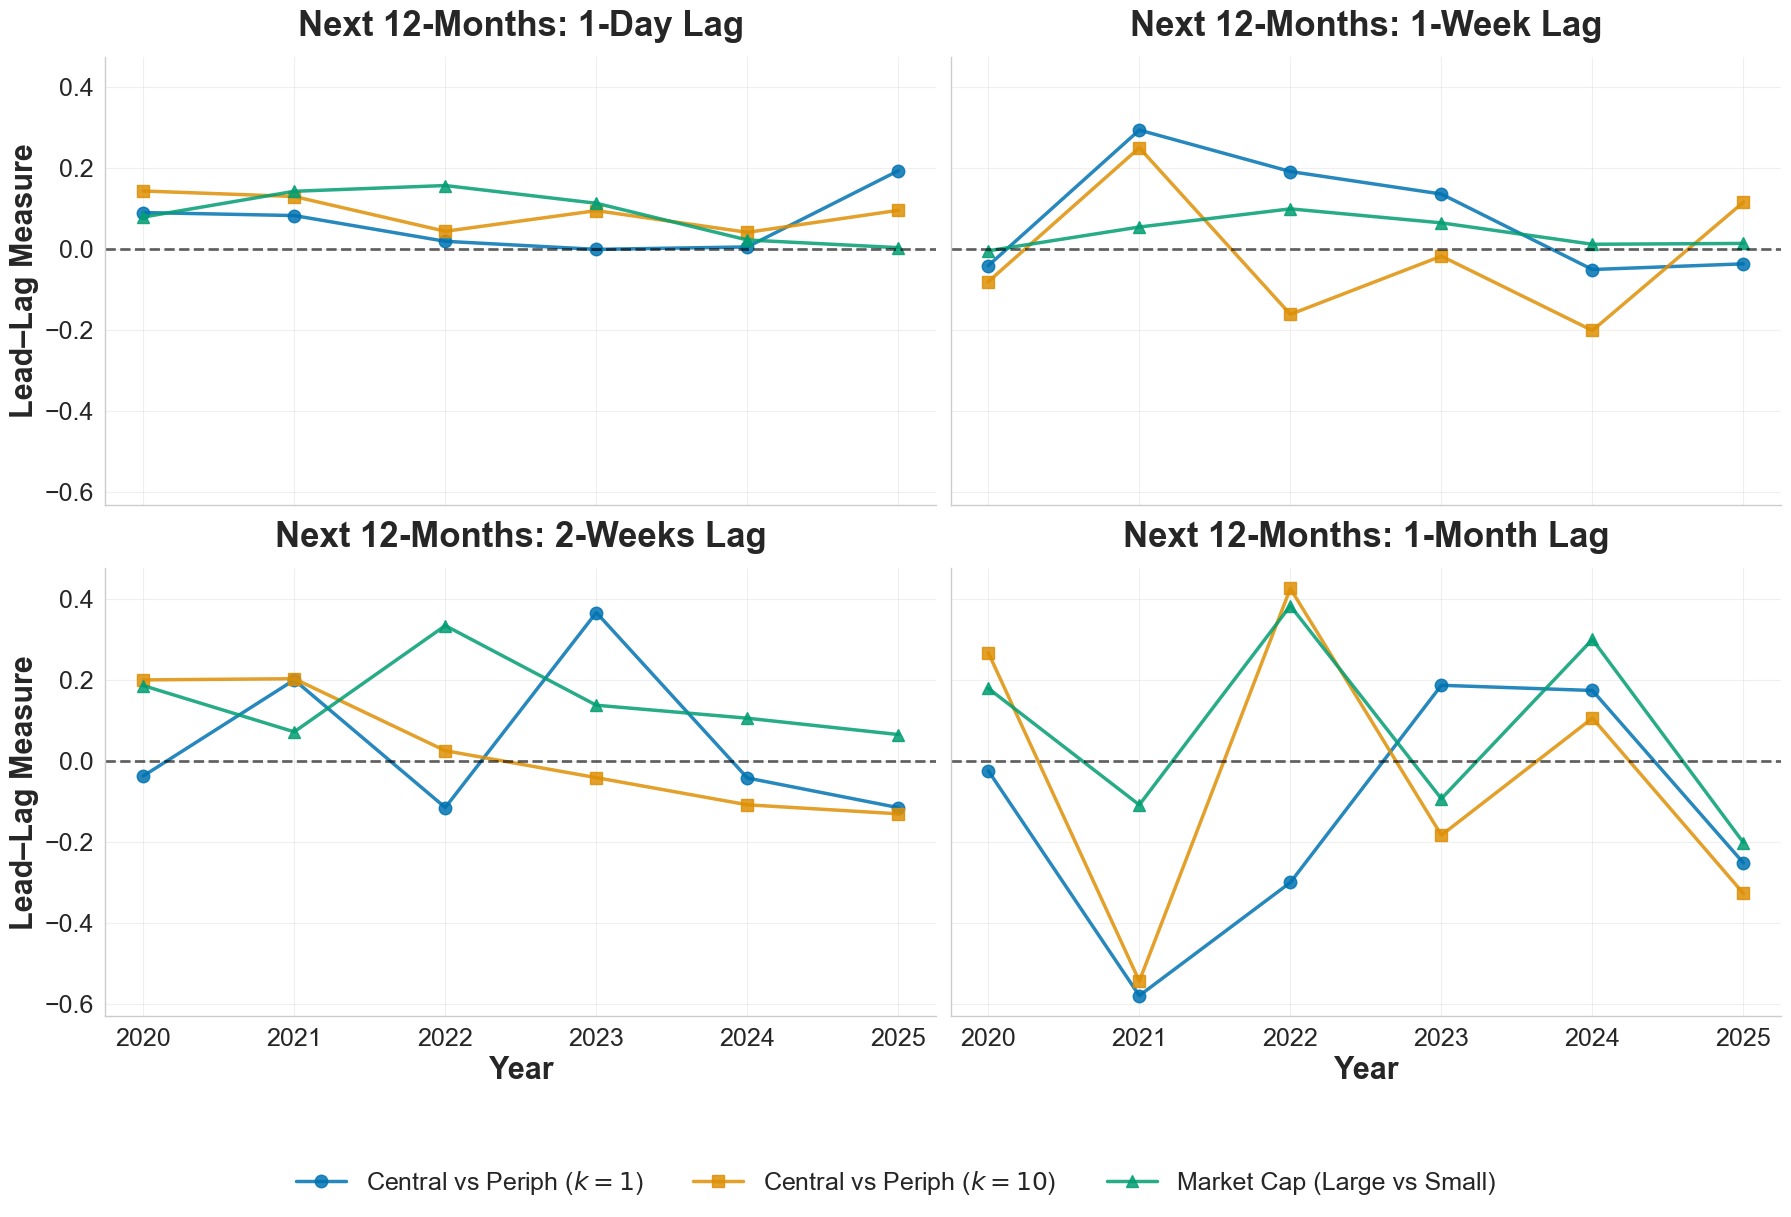

In [7]:
out_of_sample_lead_lag(n_months=12)